# **Step 1 - Problem Understanding**

***Problem Definition***

The goal is simple: we need to build a system that accurately reads customer feedback and sorts it into "Positive" or "Negative" categories. Using a subset of Amazon’s Product Reviews Polarity dataset, we are developing a model to handle the messy, raw text of real-world reviews and extract clear sentiment.

***Type of Data***

We are working with 10,000 text samples from Amazon. This provides enough volume to train a deep learning model while remaining computationally efficient for this analysis.

***Industry Relevance***

In e-commerce, you can’t manually read every comment once you hit a certain scale. It’s too slow and inconsistent. By automating this, companies can monitor their brand reputation in real-time, catch product defects before they trend, and prioritize customer service hits, turning raw data into actionable business intelligence to help larger scale decisions.

***Motivation for Deep Learning and Transformers***

Standard machine learning often misses the feel or even the "vibe" of a sentence because it treats words as isolated units.

LSTM (Standard Deep Learning): We use this as our first step because it views language as a sequence, which is how humans read.

Transformers (BERT/DistilBERT): We’re implementing these to leverage the concept of Self-Attention. Unlike older models, Transformers look at every word in a review simultaneously to understand context. This is the difference between reading a sentence word-by-word and understanding the bigger picture of a customer's tone.

***Research Questions and Objectives***

We are testing our approach against three benchmarks:


1.   Generalization: Can a standard LSTM actually handle the variety and slang found in 10,000 diverse product reviews?

2.   The Transformer Advantage: Does DistilBERT’s parallel processing and attention mechanism actually lead to fewer mistakes than the sequential approach of an LSTM?

3.   Real-World Impact: How much of an accuracy boost do these deep learning architectures provide over traditional methods when it comes to automated decision-making?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split

# 1. Load 10,000 samples for training and 2,000 for testing
raw_train = load_dataset("amazon_polarity", split='train[:10000]')
raw_test = load_dataset("amazon_polarity", split='test[:2000]')

# Convert to Pandas for easier exploration and cleaning
train_df = pd.DataFrame(raw_train)
test_df = pd.DataFrame(raw_test)

print(f"Initial training samples: {len(train_df)}")
print(f"Initial testing samples: {len(test_df)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

amazon_polarity/train-00000-of-00004.par(…):   0%|          | 0.00/260M [00:00<?, ?B/s]

amazon_polarity/train-00001-of-00004.par(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

amazon_polarity/train-00002-of-00004.par(…):   0%|          | 0.00/255M [00:00<?, ?B/s]

amazon_polarity/train-00003-of-00004.par(…):   0%|          | 0.00/254M [00:00<?, ?B/s]

amazon_polarity/test-00000-of-00001.parq(…):   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

Initial training samples: 10000
Initial testing samples: 2000


# ***Step 2 – Data Preparation***

Missing values in Training set:
label      0
title      0
content    0
dtype: int64


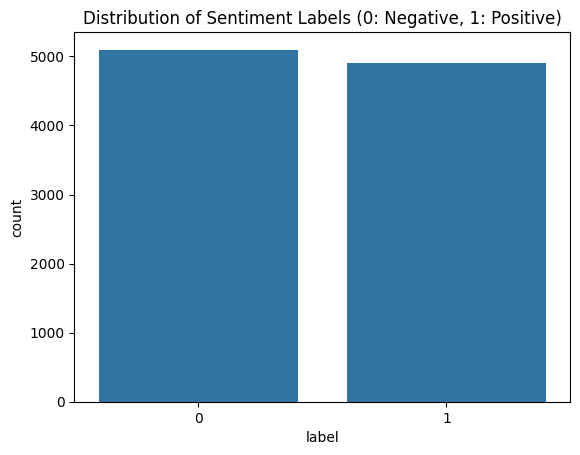

In [2]:
# Check for null values
print("Missing values in Training set:")
print(train_df.isnull().sum())

# Visualize class distribution (0 = Negative, 1 = Positive)
sns.countplot(x='label', data=train_df)
plt.title('Distribution of Sentiment Labels (0: Negative, 1: Positive)')
plt.show() # Visualization generated as code output per rubric [cite: 132]

In [3]:
def clean_and_combine(df):
    # Combine title and content for better feature representation [cite: 78]
    df['text'] = df['title'] + " " + df['content']
    # Ensure text is lowercase and stripped of extra whitespace
    df['text'] = df['text'].str.lower().str.strip()
    return df[['text', 'label']]

train_df = clean_and_combine(train_df)
test_df = clean_and_combine(test_df)

In [4]:
# Split the 10,000 training samples into 80% Train and 20% Temp (to be split again)
# random_state ensures reproducibility, which is critical for the interview phase [cite: 157]
X_train, X_val, y_train, y_val = train_test_split(
    train_df['text'],
    train_df['label'],
    test_size=0.125, # Leads to 10% of total (1000 samples) for validation
    random_state=42
)

# Test set is already defined as test_df (2000 samples)
print(f"Final Training samples: {len(X_train)}")
print(f"Final Validation samples: {len(X_val)}")
print(f"Final Testing samples: {len(test_df)}")

Final Training samples: 8750
Final Validation samples: 1250
Final Testing samples: 2000


# ***Feature Engineering***

In [6]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import AutoTokenizer
import numpy as np

# 1. Representation for Standard LSTM, ALSO ignore the squiggly lines for the tensorflow library stuff on the top of this cell, it works for me but we can revisit if it doesnt for you
MAX_VOCAB = 10000 # Limit to top 10k words
MAX_LEN = 100    # Standardize review length

# Initialize and fit the Keras tokenizer
tokenizer_lstm = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer_lstm.fit_on_texts(X_train)

# Convert text to padded sequences
X_train_seq = pad_sequences(tokenizer_lstm.texts_to_sequences(X_train), maxlen=MAX_LEN)
X_val_seq = pad_sequences(tokenizer_lstm.texts_to_sequences(X_val), maxlen=MAX_LEN)
X_test_seq = pad_sequences(tokenizer_lstm.texts_to_sequences(test_df['text']), maxlen=MAX_LEN)

# 2. Representation for Transformer (DistilBERT)
# We use DistilBERT as a faster, more efficient version of BERT for limited timeframes
model_checkpoint = "distilbert-base-uncased"
tokenizer_transformer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_for_transformer(texts):
    return tokenizer_transformer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="np" # Changed from "tf" to "np" to resolve the ValueError, numpy handles these better anyways lol
    )

# Now re-run the tokenization
X_train_tf = tokenize_for_transformer(X_train)
X_val_tf = tokenize_for_transformer(X_val)
X_test_tf = tokenize_for_transformer(test_df['text'])

print("Feature representation fixed and complete.")

# Pre-tokenize the data for the Transformer model
X_train_tf = tokenize_for_transformer(X_train)
X_val_tf = tokenize_for_transformer(X_val)
X_test_tf = tokenize_for_transformer(test_df['text'])

print("Feature representation complete.")
print(f"LSTM input shape: {X_train_seq.shape}")
print(f"Transformer input IDs shape: {X_train_tf['input_ids'].shape}")

Feature representation fixed and complete.
Feature representation complete.
LSTM input shape: (8750, 100)
Transformer input IDs shape: (8750, 100)
